<a href="https://colab.research.google.com/github/Stellamatt0303/FINTECH-P2-MATTEUCCI-CHERVENKA-/blob/main/FINA4075_P2_StrategyLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINA 4075/5075 — Project 0 Starter Notebook (Fall 2026)

**Before running anything:** File → **Save a copy in Drive**, then Runtime → Change runtime type → **Runtime version 2026.07** (Rule 0).

Follow the Project 0 Detailed Student Instructions (D2L). Run cells top to bottom; finish with **Runtime → Restart session and run all** — it must complete with no errors before you submit.

In [1]:
# Cell 1 — mount Drive (Rule 1)
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Cell 2 — create the course folder
import os
P0 = "/content/drive/MyDrive/FINA4075/P0"
os.makedirs(P0, exist_ok=True)
print("Folder ready:", P0)

Folder ready: /content/drive/MyDrive/FINA4075/P0


In [3]:
# Cell 3 — pinned setup (Rule 2; -q omitted in P0 on purpose)
# Official pinned line (Fall 2026), as posted in D2L (Rule 2).
%pip install yfinance==0.2.66

In [4]:
# Cell 4 — environment stamp (Rule 0)
import sys, pandas as pd, numpy as np, matplotlib, yfinance as yf
print(sys.version)
print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| yfinance", yf.__version__)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | yfinance 0.2.66


### Project 2 Setup & File Verification

In [5]:
# Project 2 — locate the required files
from pathlib import Path

P2_DIR = Path("/content/drive/MyDrive/FINA4075/P2")

panel_path = P2_DIR / "panel_returns_2026-08-31.csv"
ticker_path = P2_DIR / "P2_ticker_list_2026-08-31.csv"

print("Project 2 folder:", P2_DIR)
print("Panel exists:", panel_path.exists())
print("Ticker list exists:", ticker_path.exists())

assert panel_path.exists(), f"Panel file not found: {panel_path}"
assert ticker_path.exists(), f"Ticker-list file not found: {ticker_path}"

Project 2 folder: /content/drive/MyDrive/FINA4075/P2
Panel exists: True
Ticker list exists: True


In [6]:
# Project 2 — load and validate the panel
panel = pd.read_csv(panel_path, index_col=0)

print("Panel shape:", panel.shape)

assert panel.shape == (92, 200), (
    f"Expected panel shape (92, 200), but received {panel.shape}"
)

display(panel.head())

Panel shape: (92, 200)


,NYT,MTCH,SIRI,MSGS,SNAP,LUMN,TTD,NXST,IRDM,TDS,...,NJR,OGS,SR,NWE,OTTR,AWR,CPK,AVA,CWT,MGEE
date,,,,,,,,,,,,,,,,,,,,,
2019-01-31,0.155454,0.250643,0.021016,0.038102,0.212341,0.011222,0.229364,0.061420,0.050406,0.113092,...,0.061967,0.032036,0.071409,0.075201,-0.023973,0.010143,0.114022,-0.014830,0.039026,0.072548
2019-02-28,0.277713,0.035334,0.019229,0.036848,0.467066,-0.139035,0.384497,0.177107,0.098556,-0.115130,...,-0.002062,0.058599,-0.000630,0.072446,0.045157,0.054536,-0.006183,-0.025312,0.054622,-0.000805
2019-03-29,0.000000,0.022210,-0.043845,0.017318,0.124490,-0.072118,0.002076,0.108872,0.241897,-0.036221,...,0.034735,0.029844,0.045251,0.035713,-0.009149,0.002391,0.017360,0.005197,0.043444,0.063361
2019-04-30,0.010640,0.066949,0.024691,0.065875,0.010889,-0.047540,0.118868,0.080096,0.038578,0.037423,...,0.005824,-0.005728,0.023089,-0.007954,0.029707,-0.001824,0.015678,0.062038,-0.071665,-0.002648
2019-05-31,-0.040121,0.136589,-0.084144,-0.053130,0.067325,-0.063047,-0.102357,-0.140814,-0.219592,-0.096298,...,-0.052516,-0.005223,-0.010334,0.015605,-0.025094,0.028772,-0.020077,-0.022931,-0.019313,-0.017895


In [7]:
# Project 2 — calculate and verify the panel SHA-256
from pathlib import Path
import hashlib

# Define the file location
P2_DIR = Path("/content/drive/MyDrive/FINA4075/P2")
panel_path = P2_DIR / "panel_returns_2026-08-31.csv"

# Confirm the file exists
assert panel_path.exists(), f"Panel file not found: {panel_path}"

def sha256_file(file_path):
    sha = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            sha.update(block)

    return sha.hexdigest()

actual_hash = sha256_file(panel_path)
expected_hash = "c9d3340eba3a3301a63bb788c87f1d6e9e55de58a3fec16b12a34b313cac076b"

print("Actual SHA-256:  ", actual_hash)
print("Expected SHA-256:", expected_hash)

assert actual_hash.lower() == expected_hash.lower(), (
    "SHA-256 does not match the Data Dictionary."
)

print("SHA-256 verified successfully.")

Actual SHA-256:   c9d3340eba3a3301a63bb788c87f1d6e9e55de58a3fec16b12a34b313cac076b
Expected SHA-256: c9d3340eba3a3301a63bb788c87f1d6e9e55de58a3fec16b12a34b313cac076b
SHA-256 verified successfully.


In [8]:
# Pre-commit exploration — load company information
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

P2_DIR = Path("/content/drive/MyDrive/FINA4075/P2")
company_path = P2_DIR / "FINA 4075-5075 Project 2 - Company List - Fall 2026.xlsx"

# Check if file exists; if not, raise a helpful instruction message
if not company_path.exists():
    msg = (
        f"\n{'='*70}\n"
        f"ERROR: The file '{company_path.name}' is missing!\n\n"
        f"Please follow these steps to fix this error:\n"
        f"1. Download the Excel workbook from D2L.\n"
        f"2. Upload it to your Google Drive folder: FINA4075/P2/\n"
        f"3. Rerun this cell once the upload is finished.\n"
        f"{'='*70}\n"
    )
    raise FileNotFoundError(msg)

companies = pd.read_excel(company_path, sheet_name="Company List")

# Work with a separate copy; do not change the original CSV
explore_returns = panel.copy()
explore_returns.index = pd.to_datetime(explore_returns.index)
explore_returns = explore_returns.sort_index()
explore_returns.columns = explore_returns.columns.str.strip()

companies["Ticker"] = companies["Ticker"].str.strip()
assert companies["Ticker"].is_unique, "Duplicate tickers in company list."

company_info = companies.set_index("Ticker")

missing_tickers = explore_returns.columns.difference(company_info.index)
assert len(missing_tickers) == 0, f"Unmatched tickers: {missing_tickers.tolist()}"

print("Company list loaded:", len(companies), "companies")
print("Sectors:", companies["Sector"].nunique())
print("Missing return values:", explore_returns.isna().sum().sum())

display(companies[["Ticker", "Company", "Sector"]].head())

Company list loaded: 200 companies
Sectors: 11
Missing return values: 0


,Ticker,Company,Sector
0,NYT,The New York Times Company,Communication Services
1,MTCH,"Match Group, Inc.",Communication Services
2,SIRI,Sirius XM Holdings Inc.,Communication Services
3,MSGS,Madison Square Garden Sports Corp.,Communication Services
4,SNAP,Snap Inc.,Communication Services


In [9]:
# Historical summary statistics for all 200 stocks
stock_summary = pd.DataFrame({
    "Mean monthly return": explore_returns.mean(),
    "Monthly volatility": explore_returns.std(ddof=1),
    "Worst month": explore_returns.min(),
    "Best month": explore_returns.max(),
    "Months available": explore_returns.count()
})

stock_summary = stock_summary.join(company_info[["Company", "Sector"]])

display(
    stock_summary.head(10).style.format({
        "Mean monthly return": "{:.2%}",
        "Monthly volatility": "{:.2%}",
        "Worst month": "{:.2%}",
        "Best month": "{:.2%}"
    })
)

print("Summary across the 200 stocks:")
display(stock_summary.iloc[:, :5].describe().round(4))

,Mean monthly return,Monthly volatility,Worst month,Best month,Months available,Company,Sector
NYT,1.74%,9.74%,-19.11%,27.77%,92,The New York Times Company,Communication Services
MTCH,0.66%,11.64%,-27.21%,30.44%,92,"Match Group, Inc.",Communication Services
SIRI,-0.08%,9.50%,-28.12%,27.25%,92,Sirius XM Holdings Inc.,Communication Services
MSGS,1.13%,7.99%,-21.06%,19.97%,92,Madison Square Garden Sports Corp.,Communication Services
SNAP,1.72%,18.45%,-50.42%,50.86%,92,Snap Inc.,Communication Services
LUMN,1.82%,26.71%,-35.24%,186.36%,92,"Lumen Technologies, Inc.",Communication Services
TTD,1.82%,18.50%,-40.75%,59.07%,92,"The Trade Desk, Inc.",Communication Services
NXST,1.85%,11.13%,-49.79%,28.61%,92,"Nexstar Media Group, Inc.",Communication Services
IRDM,1.87%,12.66%,-29.25%,40.84%,92,Iridium Communications Inc.,Communication Services
TDS,1.78%,21.25%,-38.00%,167.96%,92,"Telephone and Data Systems, Inc.",Communication Services


Summary across the 200 stocks:


,Mean monthly return,Monthly volatility,Worst month,Best month,Months available
count,200.0000,200.0000,200.0000,200.0000,200.0
mean,0.0152,0.1129,-0.3058,0.4041,92.0
std,0.0096,0.0463,0.1424,0.3228,0.0
min,-0.0008,0.0539,-0.8143,0.1179,92.0
25%,0.0082,0.0785,-0.3804,0.2216,92.0
50%,0.0136,0.1028,-0.2805,0.3087,92.0
75%,0.0188,0.1323,-0.1891,0.4426,92.0
max,0.0575,0.3561,-0.1099,2.3396,92.0


In [10]:
# Signal for each portfolio month:
# standard deviation of the previous 36 months, excluding that month
low_vol_signal = (
    explore_returns.shift(1)
    .rolling(window=36, min_periods=36)
    .std(ddof=1)
)

portfolio_month = explore_returns.index[-1]
latest_signal = low_vol_signal.iloc[-1].dropna()

assert len(latest_signal) >= 20, "Not enough stocks with 36 months of data."

ranking = latest_signal.rename("Monthly volatility").to_frame()
ranking.index.name = "Ticker"
ranking = ranking.reset_index()

# Lowest volatility first; alphabetical ticker breaks ties
ranking = ranking.sort_values(
    ["Monthly volatility", "Ticker"],
    ascending=[True, True]
)

selected20 = (
    ranking.head(20)
    .set_index("Ticker")
    .join(company_info[["Company", "Sector"]])
)

selected20["Annualized volatility"] = (
    selected20["Monthly volatility"] * np.sqrt(12)
)
selected20["Weight"] = 1 / 20

print("Illustrative portfolio month:", portfolio_month.strftime("%B %Y"))
print(
    "Signal uses:",
    explore_returns.index[-37].strftime("%B %Y"),
    "through",
    explore_returns.index[-2].strftime("%B %Y")
)

display(selected20.style.format({
    "Monthly volatility": "{:.2%}",
    "Annualized volatility": "{:.2%}",
    "Weight": "{:.0%}"
}))

Illustrative portfolio month: August 2026
Signal uses: August 2023 through July 2026


,Monthly volatility,Company,Sector,Annualized volatility,Weight
Ticker,,,,,
AWR,4.30%,American States Water Company,Utilities,14.88%,5%
OGE,4.59%,OGE Energy Corp.,Utilities,15.89%,5%
KRG,4.69%,Kite Realty Group Trust,Real Estate,16.24%,5%
NJR,5.02%,New Jersey Resources Corporation,Utilities,17.39%,5%
IDA,5.02%,"IDACORP, Inc.",Utilities,17.39%,5%
POR,5.02%,Portland General Electric Company,Utilities,17.40%,5%
ADC,5.07%,Agree Realty Corporation,Real Estate,17.58%,5%
CWT,5.19%,California Water Service Group,Utilities,17.97%,5%
BRX,5.23%,Brixmor Property Group Inc.,Real Estate,18.13%,5%


,Panel stocks,Selected stocks,Panel weight,Selected weight
Sector,,,,
Communication Services,18,0,9.0%,0%
Consumer Discretionary,18,0,9.0%,0%
Consumer Staples,18,2,9.0%,10%
Energy,18,0,9.0%,0%
Financials,19,0,9.5%,0%
Health Care,18,0,9.0%,0%
Industrials,19,0,9.5%,0%
Information Technology,18,0,9.0%,0%
Materials,18,0,9.0%,0%


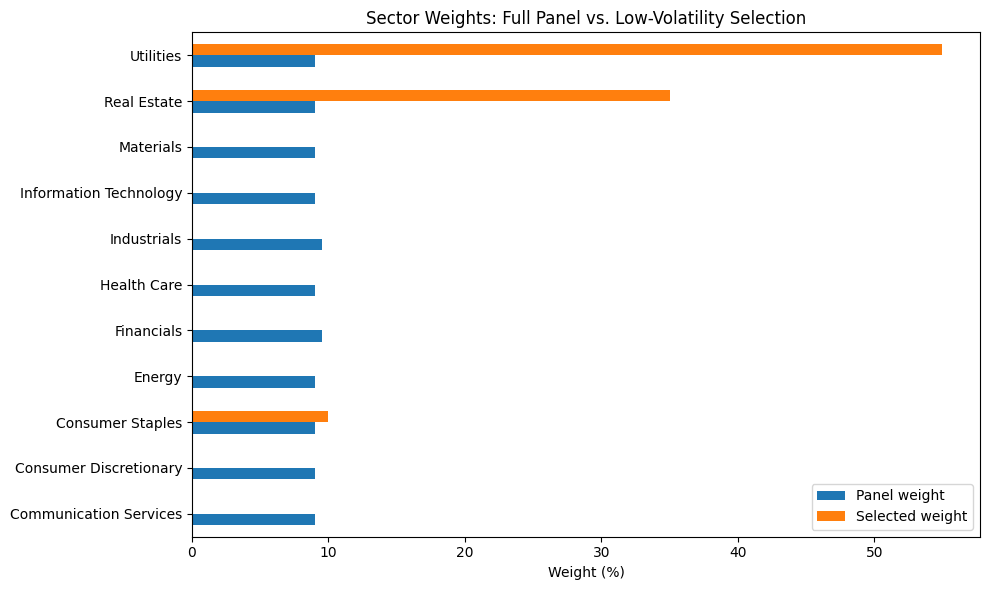

In [11]:
# Compare selected portfolio weights with full-panel sector weights
full_sector_counts = (
    company_info.loc[explore_returns.columns, "Sector"]
    .value_counts()
)

selected_sector_counts = selected20["Sector"].value_counts()

sector_comparison = pd.DataFrame({
    "Panel stocks": full_sector_counts,
    "Selected stocks": selected_sector_counts
}).fillna(0).astype(int).sort_index()

sector_comparison["Panel weight"] = (
    sector_comparison["Panel stocks"] / explore_returns.shape[1]
)
sector_comparison["Selected weight"] = (
    sector_comparison["Selected stocks"] / 20
)

display(sector_comparison.style.format({
    "Panel weight": "{:.1%}",
    "Selected weight": "{:.0%}"
}))

# Display weights as percentages
ax = (
    sector_comparison[["Panel weight", "Selected weight"]] * 100
).plot.barh(figsize=(10, 6))

ax.set_title("Sector Weights: Full Panel vs. Low-Volatility Selection")
ax.set_xlabel("Weight (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### August 31, 2026 Briefing Table
This section constructs the performance briefing table for all 200 stocks. It calculates:
- **1M**: Return for the most recent month (August 2026)
- **3M**: Cumulative return over the last 3 months (June 2026 through August 2026)
- **12M**: Cumulative return over the last 12 months (September 2025 through August 2026)

In [12]:
import pandas as pd
import numpy as np

# Create a separate working copy
briefing_returns = panel.copy()
briefing_returns.index = pd.to_datetime(briefing_returns.index)
briefing_returns = briefing_returns.sort_index()

# Include only information available through August 2026
as_of = pd.Timestamp("2026-08-31")
briefing_returns = briefing_returns.loc[
    briefing_returns.index.to_period("M") <= as_of.to_period("M")
]

# Validate dates and data
months = briefing_returns.index.to_period("M")
expected_months = pd.period_range("2025-09", "2026-08", freq="M")

assert months[-12:].equals(expected_months), (
    "The last 12 rows must be September 2025 through August 2026."
)
assert briefing_returns.shape[1] == 200
assert np.isfinite(briefing_returns.iloc[-12:].to_numpy()).all(), (
    "Missing or non-finite returns in the briefing window."
)

# Calculate compounded trailing returns
briefing_table = pd.DataFrame({
    "1M": briefing_returns.iloc[-1],
    "3M": (1 + briefing_returns.iloc[-3:]).prod() - 1,
    "12M": (1 + briefing_returns.iloc[-12:]).prod() - 1
})

# Add company information and explicitly name the ticker index
briefing_table = briefing_table.join(
    company_info[["Company", "Sector"]]
)
briefing_table.index.name = "Ticker"

briefing_table = (
    briefing_table.reset_index()
    [["Ticker", "Company", "Sector", "1M", "3M", "12M"]]
    .sort_values("Ticker")
)

assert len(briefing_table) == 200
assert briefing_table["Ticker"].is_unique
assert not briefing_table.isna().any().any(), (
    "Missing company information or returns."
)

# Print a plain-text table for copying into the LLM chat
lines = [
    "As of: 2026-08-31",
    "Ticker | Company | Sector | 1M | 3M | 12M"
]

for row in briefing_table.itertuples(index=False):
    lines.append(
        f"{row.Ticker} | {row.Company} | {row.Sector} | "
        f"{row[3]:.2%} | {row[4]:.2%} | {row[5]:.2%}"
    )

briefing_text = "\n".join(lines)
print(briefing_text)

As of: 2026-08-31
Ticker | Company | Sector | 1M | 3M | 12M
ACAD | ACADIA Pharmaceuticals Inc. | Health Care | 11.75% | 33.47% | 11.24%
ACM | AECOM | Industrials | -6.85% | -2.36% | -45.29%
AD | Array Digital Infrastructure, Inc. | Communication Services | 5.22% | -8.74% | 3.88%
ADC | Agree Realty Corporation | Real Estate | -6.79% | -1.53% | 3.63%
AGCO | AGCO Corporation | Industrials | 16.16% | 5.69% | 10.50%
ALK | Alaska Air Group, Inc. | Industrials | -12.90% | -10.19% | -34.17%
AMG | Affiliated Managers Group, Inc. | Financials | 0.40% | 21.58% | 63.79%
AMRX | Amneal Pharmaceuticals, Inc. | Health Care | -4.64% | 32.65% | 82.74%
AOS | A. O. Smith Corporation | Industrials | -1.66% | 4.88% | -15.21%
APPF | AppFolio, Inc. | Information Technology | 29.98% | 45.32% | -15.56%
AROC | Archrock, Inc. | Energy | -11.28% | -5.26% | 30.87%
ASH | Ashland Inc. | Materials | 0.99% | 27.57% | 33.48%
AVA | Avista Corporation | Utilities | -6.96% | -9.25% | 6.73%
AVNT | Avient Corporation | Mater

Runtime - Restart session and run all - Confirm the panel shape is (92, 200) and the SHA-256 verification succeeds.


## Locked Strategy and In-Sample Backtest

The cells below implement the locked 36-month low-volatility rule and produce
the required January 2022–August 2026 backtest exhibit.


In [13]:
"""
strategy.py — LOCKED STRATEGY CODE (Track 1)
FINA 4075/5075 Project 2 — Fall 2026

Rule (strategy_rules.md governs if the two ever disagree):
  For portfolio month t, calculate each eligible stock's sample standard
  deviation over the 36 monthly total returns t-36 through t-1, with ddof=1
  and no skip-month. Rank ascending, breaking exact ties alphabetically by
  ticker. Hold the 20 lowest-volatility stocks at equal weights, rebalance
  monthly, and charge 10 basis points per side.

CODE RULE: after the pre-registration commit, rerun this file unchanged at
each checkpoint. Do not edit it in response to backtest or live results.
"""

import numpy as np
import pandas as pd


PER_SIDE = 0.0010
N_HOLD = 20
WINDOW = 36
FIRST_TRADEABLE = WINDOW       # row 36 = January 2022


def load_panel(panel_path, ticker_path):
    """Read the course files and return (rets, dates, tickers, info).

    rets: T x N NumPy array of simple monthly total returns.
    dates: month-end dates from the panel.
    tickers: ticker symbols in panel-column order.
    info: instructor ticker-list data indexed by Ticker.
    """
    panel = pd.read_csv(panel_path, index_col=0, parse_dates=True)
    info = pd.read_csv(ticker_path).set_index("Ticker")

    panel.columns = panel.columns.astype(str).str.strip()
    info.index = info.index.astype(str).str.strip()
    panel = panel.apply(pd.to_numeric, errors="raise")

    tickers = list(panel.columns)
    assert list(info.index) == tickers, "ticker list and panel columns differ"
    assert panel.index.is_monotonic_increasing, "panel dates are not chronological"
    assert panel.index.is_unique, "panel contains duplicate dates"
    assert len(tickers) == len(set(tickers)), "panel contains duplicate tickers"
    assert not np.isinf(panel.to_numpy()).any(), "panel contains infinite returns"

    return panel.to_numpy(dtype=float), panel.index, tickers, info


def signal(t, rets):
    """Sample volatility over rows t-36 through t-1 inclusive."""
    window = rets[t - WINDOW:t]
    assert window.shape[0] == WINDOW
    return np.std(window, axis=0, ddof=1)


def select_holdings(t, rets, tickers):
    """Return indices of the 20 eligible stocks with lowest volatility.

    A stock is ineligible if any return in its 36-month signal window is
    missing. Exact volatility ties are broken alphabetically by ticker.
    """
    if t < FIRST_TRADEABLE:
        raise ValueError("36 months of history are required before selection")

    window = rets[t - WINDOW:t]
    eligible = np.isfinite(window).all(axis=0)
    vol = signal(t, rets)

    candidates = [i for i in range(len(tickers)) if eligible[i]]
    if len(candidates) < N_HOLD:
        raise ValueError("fewer than 20 stocks have complete 36-month histories")

    order = sorted(candidates, key=lambda i: (vol[i], tickers[i]))
    return set(order[:N_HOLD])


def run_track(select_fn, rets, t0, t1, per_side=PER_SIDE):
    """Run a strategy from row t0 through row t1, inclusive.

    Equal weights; first month turnover = 1; later one-way turnover equals
    names entering divided by 20; monthly cost = 2 * per_side * turnover.
    Returns (values, turnovers, holdings), where values starts at 1.0.
    """
    if not (0 <= t0 <= t1 < len(rets)):
        raise ValueError("invalid backtest row range")

    previous = set()
    values = [1.0]
    turnovers = []
    holdings = []

    for t in range(t0, t1 + 1):
        current = select_fn(t, rets)
        if len(current) != N_HOLD:
            raise ValueError("selection rule must return exactly 20 holdings")

        turnover = 1.0 if not previous else len(current - previous) / N_HOLD
        gross_return = rets[t, sorted(current)].mean()
        cost = 2 * per_side * turnover
        net_return = gross_return - cost

        values.append(values[-1] * (1 + net_return))
        turnovers.append(turnover)
        holdings.append(current)
        previous = current

    return np.array(values), np.array(turnovers), holdings


def bench(rets, t0, t1):
    """Equal-weighted full-panel benchmark, monthly rebalanced, no costs."""
    if not (0 <= t0 <= t1 < len(rets)):
        raise ValueError("invalid benchmark row range")

    values = [1.0]
    for t in range(t0, t1 + 1):
        active = np.isfinite(rets[t])
        if not active.any():
            raise ValueError(f"no active benchmark stocks in row {t}")
        monthly_return = rets[t, active].mean()
        values.append(values[-1] * (1 + monthly_return))
    return np.array(values)


def stats(values, turns=None):
    """Calculate the performance measures required by the assignment."""
    values = np.asarray(values, dtype=float)
    months = len(values) - 1
    if months < 2:
        raise ValueError("at least two return months are required for statistics")

    monthly = values[1:] / values[:-1] - 1
    cagr = (values[-1] / values[0]) ** (12 / months) - 1
    vol = monthly.std(ddof=1) * np.sqrt(12)
    sharpe = cagr / vol if vol != 0 else np.nan
    maxdd = (values / np.maximum.accumulate(values) - 1).min()

    output = {
        "CAGR": cagr,
        "Annualized volatility": vol,
        "Sharpe (rf = 0)": sharpe,
        "Maximum drawdown": maxdd,
        "Growth of $10,000": 10000 * values[-1],
    }

    if turns is not None:
        turns = np.asarray(turns, dtype=float)
        if len(turns) != months:
            raise ValueError("turnover count must equal return-month count")
        output["Annual one-way turnover"] = turns.mean() * 12
        output["Cost drag per year"] = 2 * PER_SIDE * turns.mean() * 12

    return output


def run_low_volatility_backtest(rets, tickers):
    """Convenience wrapper for January 2022 through the panel's final month."""
    if len(rets) <= FIRST_TRADEABLE:
        raise ValueError("panel does not contain a tradeable month")

    select_fn = lambda t, data: select_holdings(t, data, tickers)
    t0 = FIRST_TRADEABLE
    t1 = len(rets) - 1

    strategy_values, turnovers, holdings = run_track(
        select_fn, rets, t0, t1
    )
    benchmark_values = bench(rets, t0, t1)

    return strategy_values, benchmark_values, turnovers, holdings, t0, t1


In [14]:

# Use the already verified panel and company information
panel_for_backtest = panel.copy()
panel_for_backtest.index = pd.to_datetime(panel_for_backtest.index)
panel_for_backtest = panel_for_backtest.sort_index()

rets = panel_for_backtest.to_numpy(dtype=float)
dates = panel_for_backtest.index
tickers = list(panel_for_backtest.columns)
info = company_info.copy()

assert rets.shape == (92, 200)
assert len(tickers) == len(set(tickers)) == 200
print("Backtest inputs ready:", rets.shape)


Backtest inputs ready: (92, 200)


In [15]:

# Run the locked rule from January 2022 through August 2026
strategy_values, benchmark_values, turnovers, holdings, t0, t1 = (
    run_low_volatility_backtest(rets, tickers)
)

assert len(strategy_values) - 1 == 56
assert dates[t0].to_period("M") == pd.Period("2022-01")
assert dates[t1].to_period("M") == pd.Period("2026-08")
assert all(len(month_holdings) == 20 for month_holdings in holdings)

print("Backtest months:", len(strategy_values) - 1)
print("First month:", dates[t0].date())
print("Last month:", dates[t1].date())


Backtest months: 56
First month: 2022-01-31
Last month: 2026-08-31


In [16]:

# Required performance statistics
strategy_stats = stats(strategy_values, turnovers)
benchmark_stats = stats(benchmark_values)

stats_table = pd.DataFrame({
    "Measure": [
        "CAGR",
        "Annualized volatility",
        "Sharpe (rf = 0)",
        "Maximum drawdown",
        "Annual one-way turnover",
        "Growth of $10,000",
    ],
    "36-Month Low Volatility — Net": [
        f"{strategy_stats['CAGR']:.2%}",
        f"{strategy_stats['Annualized volatility']:.2%}",
        f"{strategy_stats['Sharpe (rf = 0)']:.3f}",
        f"{strategy_stats['Maximum drawdown']:.2%}",
        f"{strategy_stats['Annual one-way turnover']:.2%}",
        f"${strategy_stats['Growth of $10,000']:,.2f}",
    ],
    "Equal-Weighted Benchmark": [
        f"{benchmark_stats['CAGR']:.2%}",
        f"{benchmark_stats['Annualized volatility']:.2%}",
        f"{benchmark_stats['Sharpe (rf = 0)']:.3f}",
        f"{benchmark_stats['Maximum drawdown']:.2%}",
        "—",
        f"${benchmark_stats['Growth of $10,000']:,.2f}",
    ],
}).set_index("Measure")

display(stats_table)

print(f"Strategy CAGR: {strategy_stats['CAGR']:.2%}")
print(f"Strategy annualized volatility: {strategy_stats['Annualized volatility']:.2%}")
print(f"Strategy Sharpe (rf = 0): {strategy_stats['Sharpe (rf = 0)']:.3f}")
print(f"Strategy maximum drawdown: {strategy_stats['Maximum drawdown']:.2%}")
print(f"Annual one-way turnover: {strategy_stats['Annual one-way turnover']:.2%}")
print(f"Strategy ending value: ${strategy_stats['Growth of $10,000']:,.2f}")
print(f"Benchmark ending value: ${benchmark_stats['Growth of $10,000']:,.2f}")


,36-Month Low Volatility — Net,Equal-Weighted Benchmark
Measure,,
CAGR,3.81%,11.83%
Annualized volatility,13.52%,17.44%
Sharpe (rf = 0),0.281,0.678
Maximum drawdown,-13.50%,-14.81%
Annual one-way turnover,112.50%,—
"Growth of $10,000","$11,903.89","$16,847.44"


Strategy CAGR: 3.81%
Strategy annualized volatility: 13.52%
Strategy Sharpe (rf = 0): 0.281
Strategy maximum drawdown: -13.50%
Annual one-way turnover: 112.50%
Strategy ending value: $11,903.89
Benchmark ending value: $16,847.44


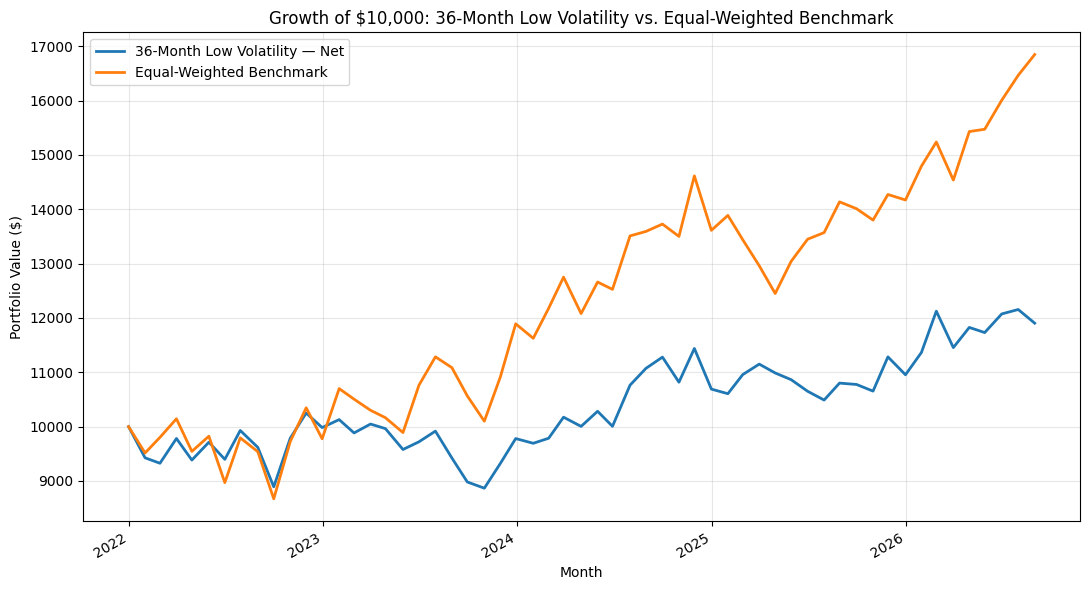

36-Month Low Volatility — Net    $11,903.89
Equal-Weighted Benchmark         $16,847.44
Name: 2026-08-31 00:00:00, dtype: object


In [17]:

# Growth-of-$10,000 exhibit
performance_dates = pd.DatetimeIndex(dates[t0:t1 + 1])
initial_date = performance_dates[0] - pd.offsets.MonthEnd(1)
growth_dates = pd.DatetimeIndex([initial_date, *performance_dates.tolist()])

growth = pd.DataFrame({
    "36-Month Low Volatility — Net": 10000 * strategy_values,
    "Equal-Weighted Benchmark": 10000 * benchmark_values,
}, index=growth_dates)

ax = growth.plot(figsize=(11, 6), linewidth=2)
ax.set_title("Growth of $10,000: 36-Month Low Volatility vs. Equal-Weighted Benchmark")
ax.set_xlabel("Month")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

assert growth.iloc[0].eq(10000).all()
print(growth.iloc[-1].map(lambda value: f"${value:,.2f}"))


In [18]:

# Hand verification — January 2022
month_t = t0
month_holdings = sorted(holdings[0])
three_indices = month_holdings[:3]

hand_check = pd.DataFrame({
    "Ticker": [tickers[i] for i in three_indices],
    "Monthly return": [rets[month_t, i] for i in three_indices],
    "Weight": [0.05] * 3,
})
hand_check["Contribution"] = hand_check["Monthly return"] * hand_check["Weight"]
display(hand_check.style.format({
    "Monthly return": "{:.4%}",
    "Weight": "{:.0%}",
    "Contribution": "{:.4%}",
}))

gross_return = rets[month_t, month_holdings].mean()
transaction_cost = 2 * PER_SIDE * 1.0
net_return = gross_return - transaction_cost
manual_value = 10000 * (1 + net_return)
backtest_value = 10000 * strategy_values[1]

print(f"Gross portfolio return: {gross_return:.6f}")
print(f"Transaction cost: {transaction_cost:.6f}")
print(f"Net portfolio return: {net_return:.6f}")
print(f"Manual ending value: ${manual_value:,.2f}")
print(f"Backtest ending value: ${backtest_value:,.2f}")
assert round(manual_value, 2) == round(backtest_value, 2)
print("Hand-check matches the backtest to the cent.")


,Ticker,Monthly return,Weight,Contribution
0,CPB,2.3772%,5%,0.1189%
1,FDS,-13.1931%,5%,-0.6597%
2,BAH,-9.5058%,5%,-0.4753%


Gross portfolio return: -0.055413
Transaction cost: 0.002000
Net portfolio return: -0.057413
Manual ending value: $9,425.87
Backtest ending value: $9,425.87
Hand-check matches the backtest to the cent.



### In-sample interpretation

The 36-month low-volatility strategy produced lower volatility and a smaller
maximum drawdown than the equal-weighted benchmark, but it also produced a
substantially lower CAGR and Sharpe ratio over the 56-month in-sample window.
These results describe the locked rule's historical arithmetic and do not
establish how it will perform during the live evaluation period.



## Step 8 — Monthly Briefing-Table Generator

This function produces the standardized table as of any available month-end.
The resulting plain-text table is the only input supplied to the frozen LLM
analyst.


In [19]:
panel_df = panel_for_backtest.copy()

# Define P2_DIR for saving files
from pathlib import Path
P2_DIR = Path('/content/drive/MyDrive/FINA4075/P2/')

import pandas as pd
import numpy as np

def generate_briefing_table(panel, company_info, as_of_month):
    """
    Generate the standardized LLM briefing table as of any available month-end.

    Output columns:
    Ticker | Company | Sector | 1M | 3M | 12M
    """

    # Create a separate working copy
    returns = panel.copy()

    # Convert dates to monthly periods and sort chronologically
    returns.index = pd.to_datetime(returns.index).to_period("M")
    returns = returns.sort_index()
    returns.columns = returns.columns.astype(str).str.strip()
    returns = returns.apply(pd.to_numeric, errors="raise")

    # Convert the requested month to a monthly period
    as_of_period = pd.Period(as_of_month, freq="M")

    assert returns.index.is_unique, "Duplicate months found."
    assert returns.columns.is_unique, "Duplicate tickers found."

    if as_of_period not in returns.index:
        raise ValueError(
            f"{as_of_period} is not available in the return panel."
        )

    # Find the row position of the requested month
    month_position = returns.index.get_loc(as_of_period)

    if month_position < 11:
        raise ValueError(
            "At least 12 months of returns are required."
        )

    # Validate that the trailing 12 months are consecutive
    actual_months = returns.index[
        month_position - 11:month_position + 1
    ]

    expected_months = pd.period_range(
        end=as_of_period,
        periods=12,
        freq="M"
    )

    assert actual_months.equals(expected_months), (
        "The trailing 12-month window is not consecutive."
    )

    # Required trailing windows
    window_1m = returns.iloc[
        month_position:month_position + 1
    ]
    window_3m = returns.iloc[
        month_position - 2:month_position + 1
    ]
    window_12m = returns.iloc[
        month_position - 11:month_position + 1
    ]

    # Return NA if any required observation in that window is missing
    ret_1m = window_1m.iloc[0].where(
        window_1m.notna().all(axis=0)
    )

    ret_3m = (
        (1 + window_3m).prod(axis=0) - 1
    ).where(
        window_3m.notna().all(axis=0)
    )

    ret_12m = (
        (1 + window_12m).prod(axis=0) - 1
    ).where(
        window_12m.notna().all(axis=0)
    )

    # Create the return table
    briefing = pd.DataFrame({
        "1M": ret_1m,
        "3M": ret_3m,
        "12M": ret_12m
    })

    briefing.index.name = "Ticker"

    # Prepare company information
    company_data = company_info.copy()
    company_data.index = (
        company_data.index.astype(str).str.strip()
    )

    # Add company name and sector
    briefing = briefing.join(
        company_data[["Company", "Sector"]],
        how="left"
    )

    # Place columns in the required order
    briefing = (
        briefing.reset_index()
        [["Ticker", "Company", "Sector", "1M", "3M", "12M"]]
        .sort_values("Ticker")
        .reset_index(drop=True)
    )

    # Required validation
    assert len(briefing) == returns.shape[1], (
        "Briefing-table row count does not match the panel."
    )
    assert briefing["Ticker"].is_unique, (
        "Duplicate tickers found in briefing table."
    )
    assert briefing["Company"].notna().all(), (
        "One or more companies did not match the company list."
    )
    assert briefing["Sector"].notna().all(), (
        "One or more sectors did not match the company list."
    )

    # Avoid breaking the pipe-delimited format
    assert not briefing["Company"].str.contains(
        "|", regex=False
    ).any(), "A company name contains the | character."

    assert not briefing["Sector"].str.contains(
        "|", regex=False
    ).any(), "A sector contains the | character."

    # Percentage-formatting function
    def format_return(value):
        if pd.isna(value):
            return "NA"
        return f"{value:.2%}"

    # Create the exact plain-text table supplied to the LLM
    lines = [
        f"As of: {as_of_period.to_timestamp(how='end'):%Y-%m-%d}",
        "Ticker | Company | Sector | 1M | 3M | 12M"
    ]

    for row in briefing.itertuples(index=False):
        lines.append(
            f"{row.Ticker} | "
            f"{row.Company} | "
            f"{row.Sector} | "
            f"{format_return(row[3])} | "
            f"{format_return(row[4])} | "
            f"{format_return(row[5])}"
        )

    briefing_text = "\n".join(lines)

    return briefing, briefing_text


In [20]:

# Generate and validate the August 31, 2026 briefing table
august_briefing, august_briefing_text = generate_briefing_table(
    panel=panel_df,
    company_info=info,
    as_of_month="2026-08",
)

assert len(august_briefing) == 200
assert august_briefing["Ticker"].nunique() == 200
assert list(august_briefing.columns) == [
    "Ticker", "Company", "Sector", "1M", "3M", "12M"
]
assert len(august_briefing_text.splitlines()) - 2 == 200
print(august_briefing_text)
print("August briefing table passed all checks.")


As of: 2026-08-31
Ticker | Company | Sector | 1M | 3M | 12M
ACAD | ACADIA Pharmaceuticals Inc. | Health Care | 11.75% | 33.47% | 11.24%
ACM | AECOM | Industrials | -6.85% | -2.36% | -45.29%
AD | Array Digital Infrastructure, Inc. | Communication Services | 5.22% | -8.74% | 3.88%
ADC | Agree Realty Corporation | Real Estate | -6.79% | -1.53% | 3.63%
AGCO | AGCO Corporation | Industrials | 16.16% | 5.69% | 10.50%
ALK | Alaska Air Group, Inc. | Industrials | -12.90% | -10.19% | -34.17%
AMG | Affiliated Managers Group, Inc. | Financials | 0.40% | 21.58% | 63.79%
AMRX | Amneal Pharmaceuticals, Inc. | Health Care | -4.64% | 32.65% | 82.74%
AOS | A. O. Smith Corporation | Industrials | -1.66% | 4.88% | -15.21%
APPF | AppFolio, Inc. | Information Technology | 29.98% | 45.32% | -15.56%
AROC | Archrock, Inc. | Energy | -11.28% | -5.26% | 30.87%
ASH | Ashland Inc. | Materials | 0.99% | 27.57% | 33.48%
AVA | Avista Corporation | Utilities | -6.96% | -9.25% | 6.73%
AVNT | Avient Corporation | Mater

In [21]:

# Save the exact August table supplied to the LLM
briefing_output_path = P2_DIR / "briefing_table_2026-08-31.txt"
briefing_output_path.write_text(august_briefing_text, encoding="utf-8")
print("Saved:", briefing_output_path)


Saved: /content/drive/MyDrive/FINA4075/P2/briefing_table_2026-08-31.txt



## Step 9 — September Holdings Verification

Track 1 is generated by the locked code. Track 2 below is the first valid
response from the frozen LLM prompt and is preserved in its original order.


In [22]:

# Track 1 September holdings use September 2023 through August 2026
september_t = len(rets)
track1_indices = select_holdings(september_t, rets, tickers)
track1_september = sorted(tickers[i] for i in track1_indices)

signal_dates = pd.DatetimeIndex(dates[-36:])
assert signal_dates[0].to_period("M") == pd.Period("2023-09")
assert signal_dates[-1].to_period("M") == pd.Period("2026-08")
assert len(track1_september) == len(set(track1_september)) == 20

track2_raw_output = "PBF, DK, OII, PTEN, AMRX, HAE, LNTH, CHEF, PSMT, MSGS, STGW, CNK, ZD, MTRN, ASH, EAT, ETSY, AMG, AVT, SLAB"
track2_september = [ticker.strip() for ticker in track2_raw_output.split(",")]

assert len(track2_september) == len(set(track2_september)) == 20
assert set(track2_september).issubset(set(tickers))

overlap = sorted(set(track1_september) & set(track2_september))

print("Track 1 September holdings:")
print(", ".join(track1_september))
print("\nTrack 2 September holdings, verbatim:")
print(track2_raw_output)
print("\nOverlap:", len(overlap), "of 20")
print(", ".join(overlap) if overlap else "None")


Track 1 September holdings:
ADC, AVA, AWR, BATRK, BKH, BRX, CPB, CTRE, CWT, IDA, INGR, KRG, NJR, NNN, NWE, OGE, OTTR, POR, SR, SWX

Track 2 September holdings, verbatim:
PBF, DK, OII, PTEN, AMRX, HAE, LNTH, CHEF, PSMT, MSGS, STGW, CNK, ZD, MTRN, ASH, EAT, ETSY, AMG, AVT, SLAB

Overlap: 0 of 20
None



## Final notebook check

Use **Runtime → Restart session and run all** in Colab. Confirm that every cell
finishes without an error, the panel remains 92 × 200, the SHA-256 check passes,
the exhibit renders, and the September holdings verification passes.
